In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns

Correlation coefficient (r): 0.9613


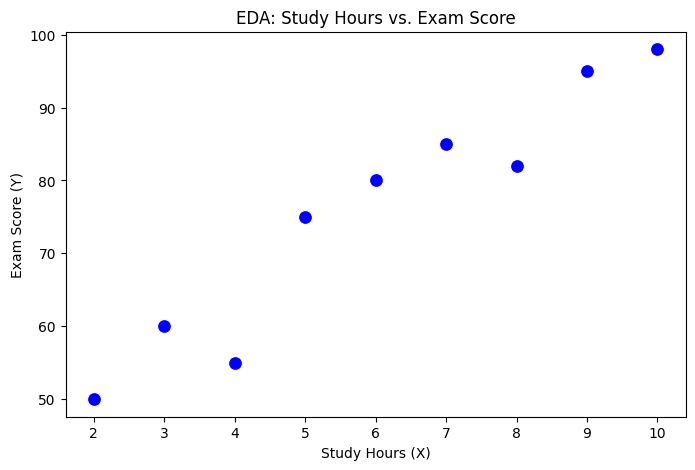

In [4]:
data = {
    'Study_Hours': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Exam_Score': [50, 60, 55, 75, 80, 85, 82, 95, 98]
}
df = pd.DataFrame(data)

X = df[['Study_Hours']]
y = df['Exam_Score']
correlation = df['Study_Hours'].corr(df['Exam_Score'])
print(f"Correlation coefficient (r): {correlation:.4f}")
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Study_Hours', y='Exam_Score', data=df, color='blue', s=100)
plt.title('EDA: Study Hours vs. Exam Score')
plt.xlabel('Study Hours (X)')
plt.ylabel('Exam Score (Y)')
plt.show()

In [8]:
model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

b0 = model.intercept_
b1 = model.coef_[0]

print("--- Model Equations ---")
print(f"y-Intercept (b0): {b0:.2f}")
print(f"Slope (b1): {b1:.2f}")
print(f"Line of Best Fit: y = {b0:.2f} + {b1:.2f}x")

--- Model Equations ---
y-Intercept (b0): 38.43
Slope (b1): 6.10
Line of Best Fit: y = 38.43 + 6.10x


--- Model Evaluation ---
R-squared (R2): 0.9228 (92.3% of variance explained)
Root Mean Squared Error (RMSE): 4.4889



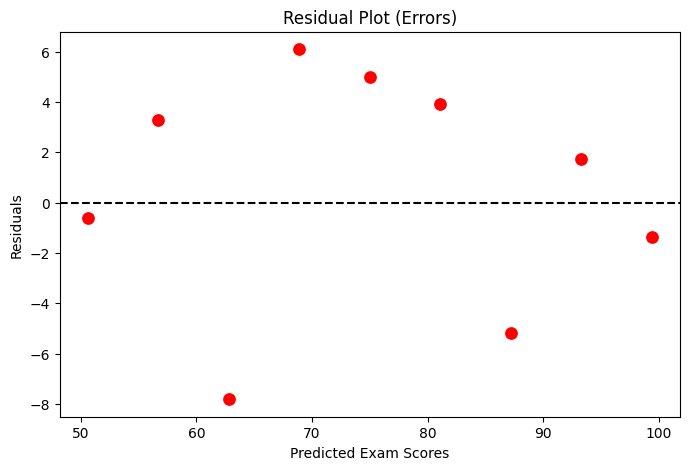

In [10]:
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))


print("--- Model Evaluation ---")
print(f"R-squared (R2): {r2:.4f} ({r2*100:.1f}% of variance explained)")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")

# Calculate residuals
residuals = y - y_pred

# Plot Residuals to check for homoscedasticity and linearity
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, color='red', s=100)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Exam Scores')
plt.ylabel('Residuals')
plt.show()

In [11]:
new_data = pd.DataFrame({'Study_Hours': [7.5]})

# Predict the outcome
predicted_score = model.predict(new_data)

print("--- Forecasting ---")
print(f"Predicted Exam Score for 7.5 hours of study: {predicted_score[0]:.2f}")

--- Forecasting ---
Predicted Exam Score for 7.5 hours of study: 84.14
